# Titanic Survival Prediction Model

Comprehensive ML pipeline to predict Titanic passenger survival using EDA, feature engineering, and multiple classification models.

## Section 0 — Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import xgboost as xgb
import re
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Table styling helper — consistent borders and formatting
def style_table(df, caption=None, precision=4, highlight_max_col=None):
    """Display a DataFrame with clean borders and formatting."""
    styled = df.style.set_table_styles([
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('border', '2px solid #2c3e50'),
            ('width', '100%'),
            ('margin', '10px 0'),
        ]},
        {'selector': 'th', 'props': [
            ('border', '1px solid #2c3e50'),
            ('padding', '8px 12px'),
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
        ]},
        {'selector': 'td', 'props': [
            ('border', '1px solid #bdc3c7'),
            ('padding', '6px 12px'),
            ('text-align', 'center'),
        ]},
        {'selector': 'tr:nth-child(even)', 'props': [
            ('background-color', '#ecf0f1'),
        ]},
        {'selector': 'tr:hover', 'props': [
            ('background-color', '#d5dbdb'),
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('border', '1px solid #2c3e50'),
            ('padding', '6px 12px'),
            ('background-color', '#34495e'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
        ]},
    ]).format(precision=precision)
    if caption:
        styled = styled.set_caption(caption).set_table_styles([
            {'selector': 'caption', 'props': [
                ('font-size', '15px'),
                ('font-weight', 'bold'),
                ('padding', '10px 0'),
                ('color', '#2c3e50'),
                ('text-align', 'left'),
            ]},
        ], overwrite=False)
    if highlight_max_col:
        styled = styled.highlight_max(subset=[highlight_max_col], color='#a9dfbf')
    display(styled)

In [ ]:
# Load data
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
style_table(train.head(10), caption='Train Data — First 10 Rows')

In [ ]:
# Extract target and prepare for unified feature engineering
target = train['Survived']
train_len = len(train)

# Combine train and test for unified feature engineering (prevents train/test skew)
all_data = pd.concat([train.drop('Survived', axis=1), test], ignore_index=True)
print(f"Combined data shape: {all_data.shape}")

missing = all_data.isnull().sum()
missing_df = pd.DataFrame({
    'Missing': missing[missing > 0],
    'Percent': (missing[missing > 0] / len(all_data) * 100).round(1)
}).sort_values('Missing', ascending=False)
style_table(missing_df, caption='Missing Values in Combined Data', precision=1)

## Section 1 — EDA

In [ ]:
# Survival rate
survival_rate = target.mean()
summary = pd.DataFrame({
    'Class': ['Died (0)', 'Survived (1)', 'Total'],
    'Count': [int((1-target).sum()), int(target.sum()), len(target)],
    'Percentage': [f'{(1-survival_rate):.1%}', f'{survival_rate:.1%}', '100.0%']
}).set_index('Class')
style_table(summary, caption='Target Distribution', precision=1)

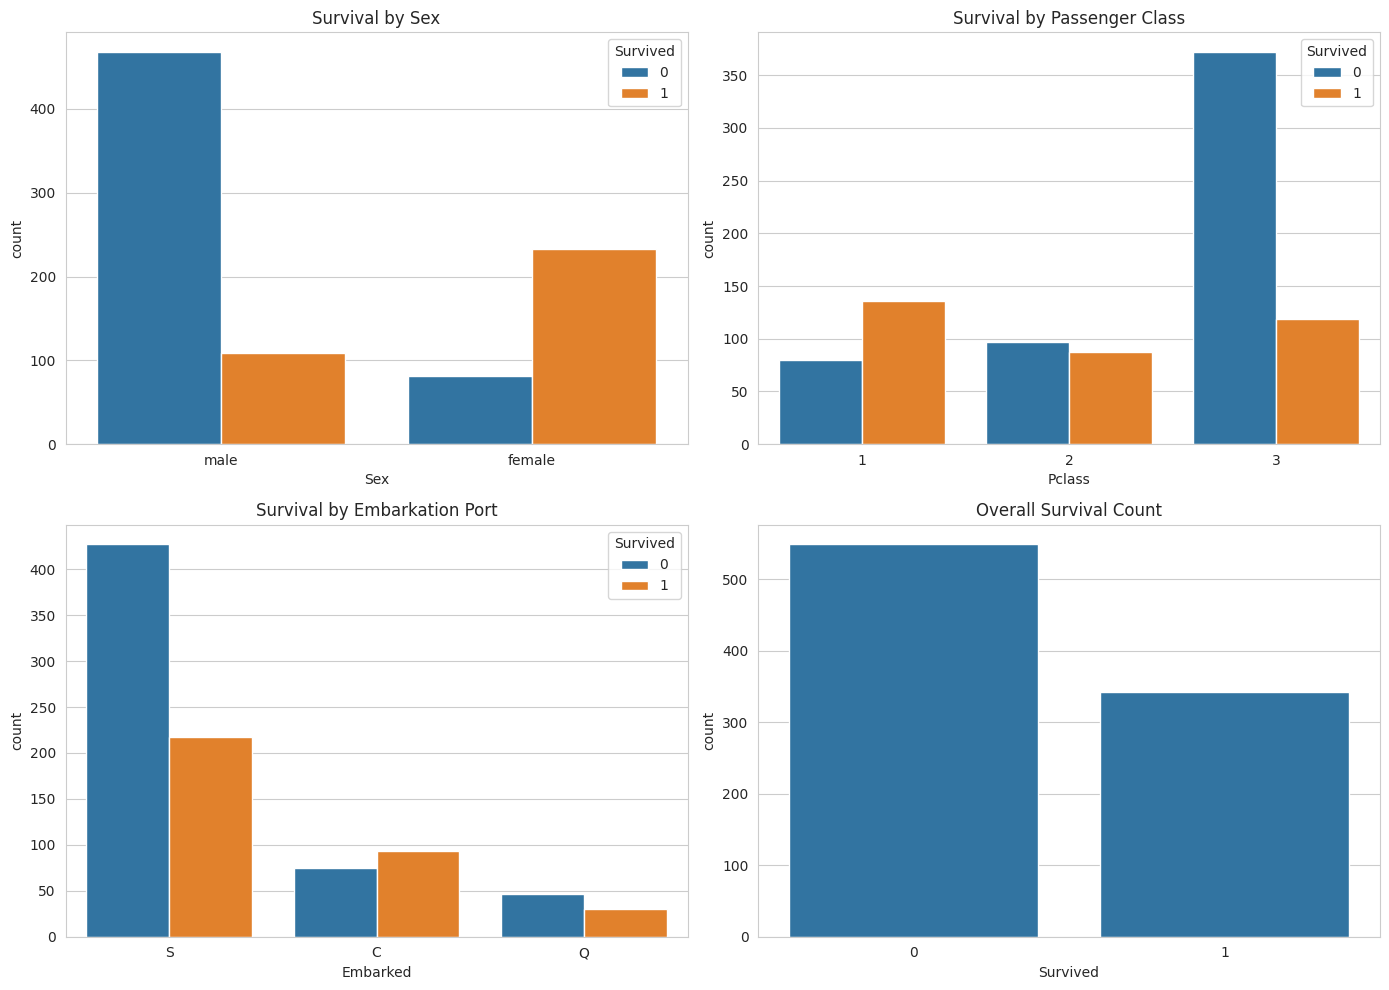

In [5]:
# Countplots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sex
sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')

# Pclass
sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Passenger Class')

# Embarked
sns.countplot(data=train, x='Embarked', hue='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival by Embarkation Port')

# Overall Survived
sns.countplot(data=train, x='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Overall Survival Count')

plt.tight_layout()
plt.show()

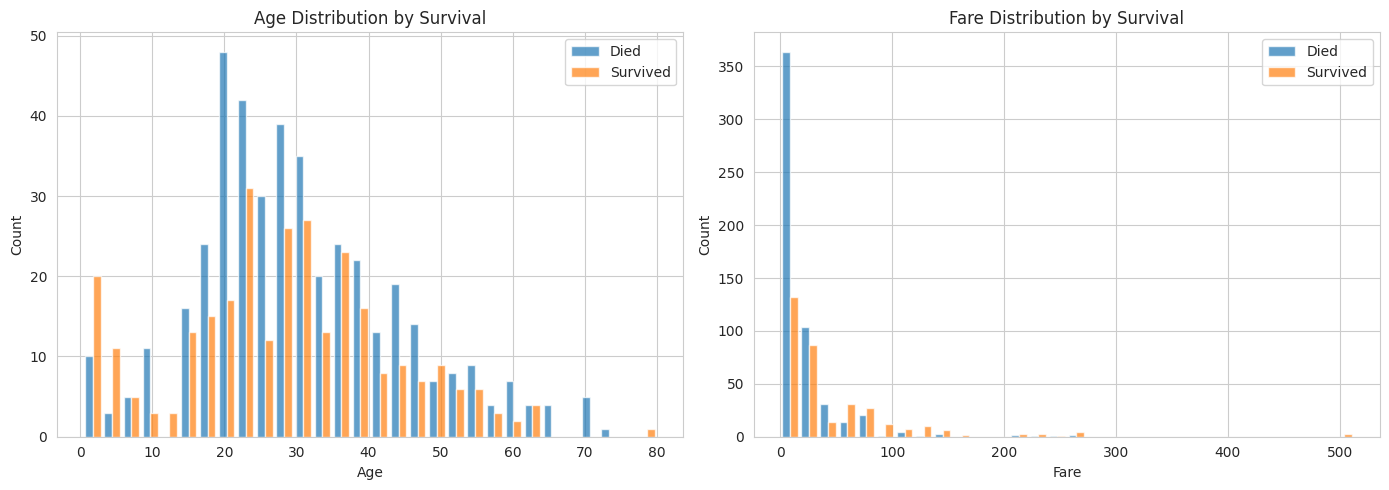

In [6]:
# Histplots for numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
axes[0].hist([train[train['Survived']==0]['Age'].dropna(),
              train[train['Survived']==1]['Age'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Survival')
axes[0].legend()

# Fare
axes[1].hist([train[train['Survived']==0]['Fare'].dropna(),
              train[train['Survived']==1]['Fare'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].set_title('Fare Distribution by Survival')
axes[1].legend()

plt.tight_layout()
plt.show()

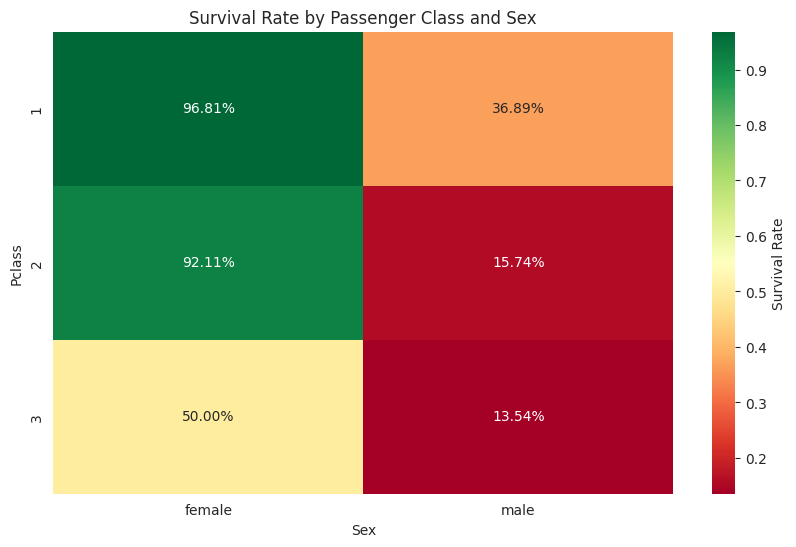

In [7]:
# Heatmap: survival rate by Pclass × Sex
survival_by_pclass_sex = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
sns.heatmap(survival_by_pclass_sex, annot=True, fmt='.2%', cmap='RdYlGn', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Passenger Class and Sex')
plt.show()

In [ ]:
# Missing value summary on combined data
missing_summary = all_data.isnull().sum()
missing_pct = (missing_summary / len(all_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_pct
})
missing_display = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
style_table(missing_display, caption='Missing Values Summary', precision=2)

## Section 2 — Feature Engineering (on all_data)

In [ ]:
# Create a copy for feature engineering
df = all_data.copy()

# Extract Title from Name
def extract_title(name):
    title_match = re.search(r' ([A-Za-z]+)\.', name)
    return title_match.group(1) if title_match else 'Unknown'

df['Title'] = df['Name'].apply(extract_title)

title_df = df['Title'].value_counts().reset_index()
title_df.columns = ['Title', 'Count']
title_df['Percentage'] = (title_df['Count'] / len(df) * 100).round(1)
style_table(title_df, caption='Extracted Title Counts (before consolidation)', precision=1)

In [ ]:
# Map titles explicitly instead of lumping by frequency
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Mrs', 'Dona': 'Mrs', 'Countess': 'Mrs',
    'Sir': 'Mr', 'Don': 'Mr', 'Jonkheer': 'Mr',
    'Col': 'Rare', 'Major': 'Rare', 'Capt': 'Rare',
    'Dr': 'Rare', 'Rev': 'Rare'
}
df['Title'] = df['Title'].replace(title_map)

# Any remaining rare titles
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

title_df = df['Title'].value_counts().reset_index()
title_df.columns = ['Title', 'Count']
title_df['Percentage'] = (title_df['Count'] / len(df) * 100).round(1)
style_table(title_df, caption='Consolidated Title Counts', precision=1)

In [ ]:
# Impute Age by Title + Pclass median
age_by_title_pclass = df.groupby(['Title', 'Pclass'])['Age'].median()

for title in df['Title'].unique():
    for pclass in df['Pclass'].unique():
        mask = (df['Title'] == title) & (df['Pclass'] == pclass) & (df['Age'].isnull())
        median_age = age_by_title_pclass.get((title, pclass), df['Age'].median())
        df.loc[mask, 'Age'] = median_age

# Fill remaining NaN with overall median
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f"Missing Age after imputation: {df['Age'].isnull().sum()}")

# Display age medians used for imputation
age_pivot = age_by_title_pclass.unstack()
age_pivot.columns = [f'Pclass {c}' for c in age_pivot.columns]
style_table(age_pivot, caption='Median Age by Title & Pclass (used for imputation)', precision=1)

In [ ]:
# Extract Deck from Cabin (A-G, T for rare, U for unknown)
df['Deck'] = df['Cabin'].fillna('U').apply(lambda x: x[0])

deck_df = df['Deck'].value_counts().reset_index()
deck_df.columns = ['Deck', 'Count']
deck_df['Percentage'] = (deck_df['Count'] / len(df) * 100).round(1)
style_table(deck_df, caption='Deck Distribution (from Cabin)', precision=1)

In [13]:
# Fill missing Fare with median
df['Fare'].fillna(df['Fare'].median(), inplace=True)
print(f"Missing Fare after imputation: {df['Fare'].isnull().sum()}")

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(f"Missing Embarked after imputation: {df['Embarked'].isnull().sum()}")

Missing Fare after imputation: 0
Missing Embarked after imputation: 0


In [ ]:
# Engineer new features

# FamilySize: total family on ship
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: binary flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# LogFare: log transform (handles Fare=0)
df['LogFare'] = np.log1p(df['Fare'])

# FareBin: quantile-based binning
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Very Low', 'Low', 'Mid', 'High'], duplicates='drop')

# AgeBin: age groups
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# Pclass x Sex Interaction: captures non-linear survival patterns
df['Pclass_1_Female'] = ((df['Pclass'] == 1) & (df['Sex'] == 'female')).astype(int)
df['Pclass_2_Female'] = ((df['Pclass'] == 2) & (df['Sex'] == 'female')).astype(int)
df['Pclass_3_Male'] = ((df['Pclass'] == 3) & (df['Sex'] == 'male')).astype(int)

# Summary table of new features
new_features = {
    'FamilySize': f"{df['FamilySize'].min():.0f} - {df['FamilySize'].max():.0f} (mean {df['FamilySize'].mean():.1f})",
    'IsAlone': f"{df['IsAlone'].sum()} alone ({df['IsAlone'].mean():.1%})",
    'LogFare': f"{df['LogFare'].min():.2f} - {df['LogFare'].max():.2f}",
    'Pclass_1_Female': f"{df['Pclass_1_Female'].sum()} passengers",
    'Pclass_2_Female': f"{df['Pclass_2_Female'].sum()} passengers",
    'Pclass_3_Male': f"{df['Pclass_3_Male'].sum()} passengers",
}
summary_df = pd.DataFrame(list(new_features.items()), columns=['Feature', 'Distribution'])
style_table(summary_df, caption='Engineered Features Summary')

## Section 3 — Preprocessing

In [ ]:
# Select final features — restore Fare + Deck, keep interaction features
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'LogFare',
                'FamilySize', 'IsAlone', 'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked',
                'Pclass_1_Female', 'Pclass_2_Female', 'Pclass_3_Male']

df = df[feature_cols].copy()

# Display feature info as a table
dtype_df = pd.DataFrame({
    'Feature': df.columns,
    'Type': df.dtypes.astype(str).values,
    'Non-Null': df.notnull().sum().values,
    'Unique': df.nunique().values,
}).reset_index(drop=True)
style_table(dtype_df, caption=f'Final Feature Set ({df.shape[1]} features, {df.shape[0]} rows)', precision=0)

In [ ]:
# Encode categorical variables (drop_first=False — trees need both category columns)
df_encoded = pd.get_dummies(df, columns=['Sex', 'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked'],
                            drop_first=False)

# Convert all columns to numeric (handles category dtypes from pd.cut/pd.qcut)
df_encoded = df_encoded.astype('float64')

print(f"Encoded features: {df_encoded.shape[1]} columns")
style_table(df_encoded.head(10), caption='Encoded Features — First 10 Rows', precision=2)

In [ ]:
# Re-split into train and test
X_train = df_encoded[:train_len].copy()
X_test = df_encoded[train_len:].copy()
y_train = target.copy()

split_df = pd.DataFrame({
    'Dataset': ['X_train', 'X_test', 'y_train'],
    'Rows': [X_train.shape[0], X_test.shape[0], y_train.shape[0]],
    'Columns': [X_train.shape[1], X_test.shape[1], 1],
})
style_table(split_df, caption='Train / Test Split', precision=0)

In [18]:
# Align X_test columns to X_train (handles unseen categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"After alignment:")
print(f"X_train columns: {X_train.shape[1]}")
print(f"X_test columns: {X_test.shape[1]}")
print(f"Column mismatch: {set(X_train.columns) - set(X_test.columns)}")

After alignment:
X_train columns: 44
X_test columns: 44
Column mismatch: set()


## Section 4 — Model Training & Comparison

In [ ]:
# Initialize models — restore original hyperparameters, keep new model additions
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                            min_samples_leaf=2, random_state=42)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=4, random_state=42)

xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                               max_depth=4, random_state=42, use_label_encoder=False,
                               eval_metric='logloss')

svc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb_model,
    'SVC': svc
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate individual models
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores

# Soft Voting Ensemble
voting = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('gb', gb), ('xgb', xgb_model), ('svc', svc)],
    voting='soft'
)
voting_scores = cross_val_score(voting, X_train, y_train, cv=skf, scoring='accuracy')
cv_results['Voting Ensemble'] = voting_scores

# Build results table
results_rows = []
for name, scores in cv_results.items():
    results_rows.append({
        'Model': name,
        'Fold 1': scores[0],
        'Fold 2': scores[1],
        'Fold 3': scores[2],
        'Fold 4': scores[3],
        'Fold 5': scores[4],
        'Mean': scores.mean(),
        'Std': scores.std(),
    })
results_table = pd.DataFrame(results_rows).set_index('Model')

# Style with best mean highlighted
styled = results_table.style.set_table_styles([
    {'selector': 'table', 'props': [
        ('border-collapse', 'collapse'), ('border', '2px solid #2c3e50'),
        ('width', '100%'), ('margin', '10px 0'),
    ]},
    {'selector': 'th', 'props': [
        ('border', '1px solid #2c3e50'), ('padding', '8px 12px'),
        ('background-color', '#2c3e50'), ('color', 'white'),
        ('font-weight', 'bold'), ('text-align', 'center'),
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #bdc3c7'), ('padding', '6px 12px'), ('text-align', 'center'),
    ]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#ecf0f1')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#d5dbdb')]},
    {'selector': 'th.row_heading', 'props': [
        ('border', '1px solid #2c3e50'), ('padding', '6px 12px'),
        ('background-color', '#34495e'), ('color', 'white'),
        ('font-weight', 'bold'), ('text-align', 'left'),
    ]},
    {'selector': 'caption', 'props': [
        ('font-size', '15px'), ('font-weight', 'bold'),
        ('padding', '10px 0'), ('color', '#2c3e50'), ('text-align', 'left'),
    ]},
]).format(precision=4).set_caption(
    'Cross-Validation Results (5-Fold Stratified)'
).highlight_max(subset=['Mean'], color='#a9dfbf').highlight_min(subset=['Std'], color='#a9dfbf')
display(styled)

In [ ]:
# Select best model (likely Voting Ensemble)
best_model_name = max(cv_results, key=lambda x: cv_results[x].mean())
if best_model_name == 'Voting Ensemble':
    best_model = voting
else:
    best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} ({cv_results[best_model_name].mean():.4f})")

## Section 5 — Evaluation

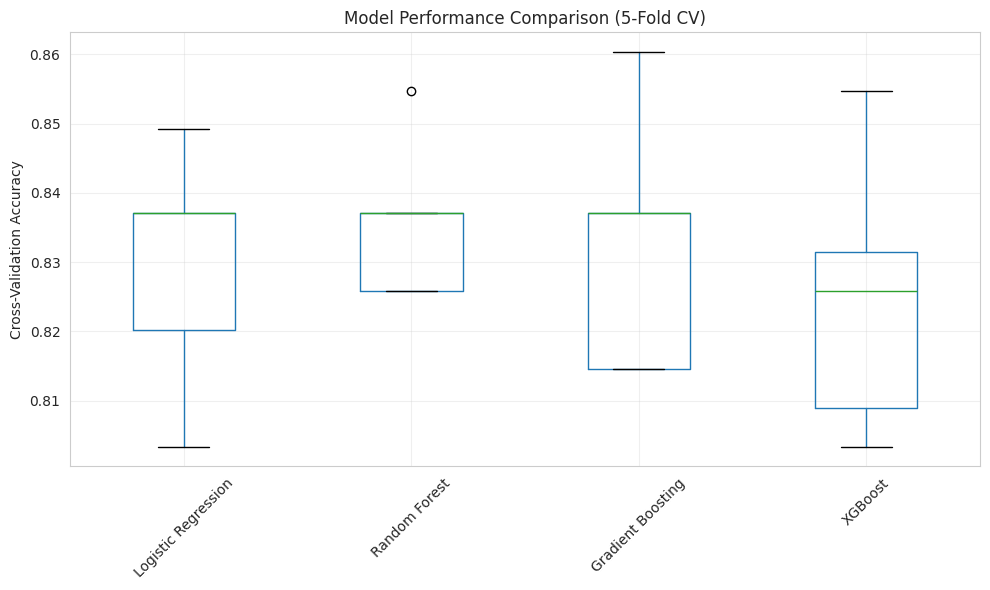

In [21]:
# Boxplot comparing CV accuracy across models
results_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
results_df.boxplot(ax=ax)
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Model Performance Comparison (5-Fold CV)')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Fit best model on full training data
best_model.fit(X_train, y_train)
y_pred_train = best_model.predict(X_train)

fit_df = pd.DataFrame({
    'Metric': ['Best Model', 'Training Accuracy', 'Train Samples'],
    'Value': [best_model_name, f"{accuracy_score(y_train, y_pred_train):.4f}", str(len(y_train))],
})
style_table(fit_df, caption='Best Model — Training Results')

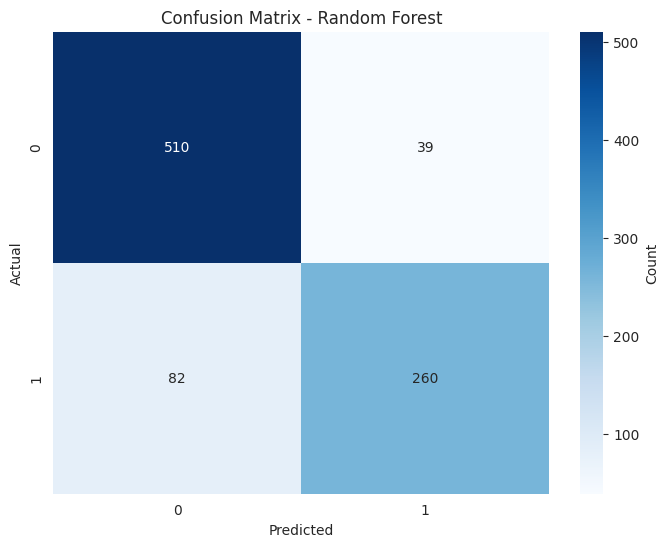

In [23]:
# Confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [ ]:
# Classification report as styled table
report = classification_report(y_train, y_pred_train, target_names=['Died', 'Survived'], output_dict=True)
report_df = pd.DataFrame(report).T
style_table(report_df, caption='Classification Report', precision=3)

In [ ]:
# Feature importance (use Random Forest from ensemble if voting, else best model)
importance_model = rf if best_model_name == 'Voting Ensemble' else best_model

if hasattr(importance_model, 'feature_importances_'):
    if best_model_name == 'Voting Ensemble':
        importance_model.fit(X_train, y_train)
    feature_importance = importance_model.feature_importances_
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    importance_df.index = importance_df.index + 1
    importance_df.index.name = 'Rank'
    
    # Plot top 15 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    colors = plt.cm.RdYlGn(np.linspace(0.8, 0.3, len(top_15)))
    ax.barh(range(len(top_15)), top_15['Importance'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 Features — {best_model_name} (RF importances)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    style_table(importance_df.head(15), caption='Top 15 Feature Importances')

elif hasattr(importance_model, 'named_steps') and hasattr(importance_model.named_steps['model'], 'coef_'):
    coef = importance_model.named_steps['model'].coef_[0]
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs Coefficient': np.abs(coef)
    }).sort_values('Abs Coefficient', ascending=False).reset_index(drop=True)
    importance_df.index = importance_df.index + 1
    importance_df.index.name = 'Rank'
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    colors = ['#27ae60' if x > 0 else '#e74c3c' for x in top_15['Coefficient']]
    ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Coefficient')
    ax.set_title(f'Top 15 Features — {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    style_table(importance_df.drop(columns=['Abs Coefficient']).head(15), caption='Top 15 Feature Coefficients')

## Section 6 — Final Prediction & Submission

In [ ]:
# Make predictions on test set
y_pred_test = best_model.predict(X_test)

pred_summary = pd.DataFrame({
    'Metric': ['Total Predictions', 'Predicted Survived', 'Predicted Died', 'Survival Rate'],
    'Value': [len(y_pred_test), int(y_pred_test.sum()), int((1-y_pred_test).sum()), f"{y_pred_test.mean():.2%}"]
})
style_table(pred_summary, caption='Test Set Predictions Summary')

In [ ]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred_test.astype(int)
})

print(f"Submission shape: {submission.shape}")
style_table(submission.head(10), caption='Submission — First 10 Rows', precision=0)
style_table(submission.tail(10), caption='Submission — Last 10 Rows', precision=0)

In [28]:
# Save submission
submission.to_csv('submission.csv', index=False)
print(f"Submission saved to ../outputs/submission.csv")

# Verify against schema
gender_submission = pd.read_csv('/kaggle/input/competitions/titanic/gender_submission.csv')
print(f"\nGender submission shape: {gender_submission.shape}")
print(f"Our submission shape: {submission.shape}")
print(f"\nSchema match: {list(submission.columns) == list(gender_submission.columns)}")
print(f"All predictions are 0 or 1: {set(submission['Survived']).issubset({0, 1})}")

Submission saved to ../outputs/submission.csv

Gender submission shape: (418, 2)
Our submission shape: (418, 2)

Schema match: True
All predictions are 0 or 1: True
